In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📊 وصف البيانات

| العمود       | الوصف |
|-------------|------|
| age         | عمر العميل |
| job         | نوع الوظيفة (إداري، فني، مدير، إلخ) |
| marital     | الحالة الاجتماعية (أعزب، متزوج، مطلق) |
| education   | مستوى التعليم (ابتدائي، ثانوي، جامعي) |
| default     | هل لديه تعثر في سداد الديون؟ (نعم/لا) |
| balance     | رصيد الحساب البنكي |
| housing     | هل لديه قرض سكني؟ (نعم/لا) |
| loan        | هل لديه قرض شخصي؟ (نعم/لا) |
| contact     | نوع وسيلة التواصل (موبايل، هاتف أرضي، غير معروف) |
| day         | يوم آخر تواصل في الشهر |
| month       | شهر آخر تواصل |
| duration    | مدة آخر مكالمة (بالثواني) |
| campaign    | عدد مرات التواصل خلال الحملة الحالية |
| pdays       | عدد الأيام منذ آخر تواصل في حملة سابقة (-1 يعني لم يتم التواصل سابقًا) |
| previous    | عدد مرات التواصل قبل هذه الحملة |
| poutcome    | نتيجة الحملة التسويقية السابقة |
| deposit     | المتغير المستهدف: هل اشترك العميل في الوديعة؟ (نعم/لا) |


In [ ]:
df = pd.read_csv('bank.csv')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5.0,may,1042.0,1.0,-1.0,0.0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5.0,may,1467.0,1.0,-1.0,0.0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5.0,may,1389.0,1.0,-1.0,0.0,unknown,yes
3,54,admin.,married,tertiary,no,184.0,no,no,unknown,5.0,may,673.0,2.0,-1.0,0.0,unknown,yes
4,42,management,single,tertiary,no,0.0,yes,yes,unknown,5.0,may,562.0,2.0,-1.0,0.0,unknown,yes


In [ ]:
df = df.replace('unknown', np.nan)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8912 entries, 0 to 8911
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8912 non-null   int64  
 1   job        8848 non-null   object 
 2   marital    8743 non-null   object 
 3   education  8496 non-null   object 
 4   default    8908 non-null   object 
 5   balance    8899 non-null   float64
 6   housing    8899 non-null   object 
 7   loan       8882 non-null   object 
 8   contact    7005 non-null   object 
 9   day        8893 non-null   float64
 10  month      8884 non-null   object 
 11  duration   8905 non-null   float64
 12  campaign   8904 non-null   float64
 13  pdays      8767 non-null   float64
 14  previous   8909 non-null   float64
 15  poutcome   2274 non-null   object 
 16  deposit    8903 non-null   object 
dtypes: float64(6), int64(1), object(10)
memory usage: 1.2+ MB


In [ ]:
df.describe()
# out --->  balance, campaign, pdays

,age,balance,day,duration,campaign,pdays,previous
count,8912.000000,8899.000000,8893.000000,8905.000000,8904.000000,8767.000000,8909.000000
mean,41.257855,1539.680638,15.684921,374.953734,2.512579,52.456941,0.834325
std,11.840567,3297.446702,8.406729,351.283501,2.772366,109.094161,2.304733
min,18.000000,-3058.000000,1.000000,3.000000,1.000000,-1.000000,0.000000
25%,32.000000,121.500000,8.000000,139.000000,1.000000,-1.000000,0.000000
50%,39.000000,553.000000,15.000000,256.000000,2.000000,-1.000000,0.000000
75%,49.000000,1726.000000,22.000000,501.000000,3.000000,64.000000,1.000000
max,95.000000,81204.000000,31.000000,3284.000000,63.000000,842.000000,58.000000


In [ ]:
df.isna().sum()

,0
age,0
job,64
marital,169
education,416
default,4
balance,13
housing,13
loan,30
contact,1907
day,19


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df = df.dropna(subset=['deposit'])

In [ ]:
# df = df.drop(columns=['duration'])

In [ ]:
X = df.drop('deposit', axis=1)
y = df['deposit']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)



In [ ]:
X_train.reset_index(drop=True,inplace=True)
X_test.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

In [ ]:
X_train.shape, X_test.shape

((7122, 16), (1781, 16))

In [ ]:
X_train.isnull().sum().sort_values(ascending=False)

,0
poutcome,5297
contact,1549
education,334
marital,133
pdays,116
job,47
loan,29
month,27
day,19
housing,11


In [ ]:
# X_train['poutcome'] = X_train['poutcome'].fillna('no_prev')
# X_test['poutcome'] = X_test['poutcome'].fillna('no_prev')

In [ ]:
cat_cols = [ 'contact', 'education', 'marital', 'job', 'loan', 'month', 'housing', 'default', 'poutcome']
num_cols = ['pdays', 'day', 'balance', 'campaign', 'previous', 'duration']


In [ ]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='median')
X_train[num_cols] = impute.fit_transform(X_train[num_cols])
X_test[num_cols] = impute.transform(X_test[num_cols])

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')

X_train[cat_cols] = imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = imputer.transform(X_test[cat_cols])

In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

/tmp/ipykernel_607/933864956.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='deposit', palette='viridis')


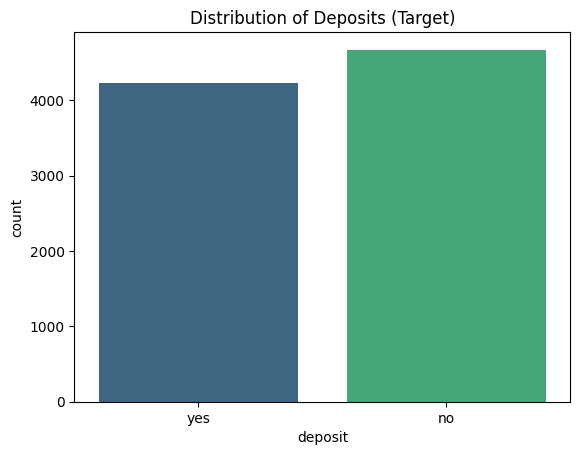

In [ ]:
sns.countplot(data=df, x='deposit', palette='viridis')
plt.title('Distribution of Deposits (Target)')
plt.show()

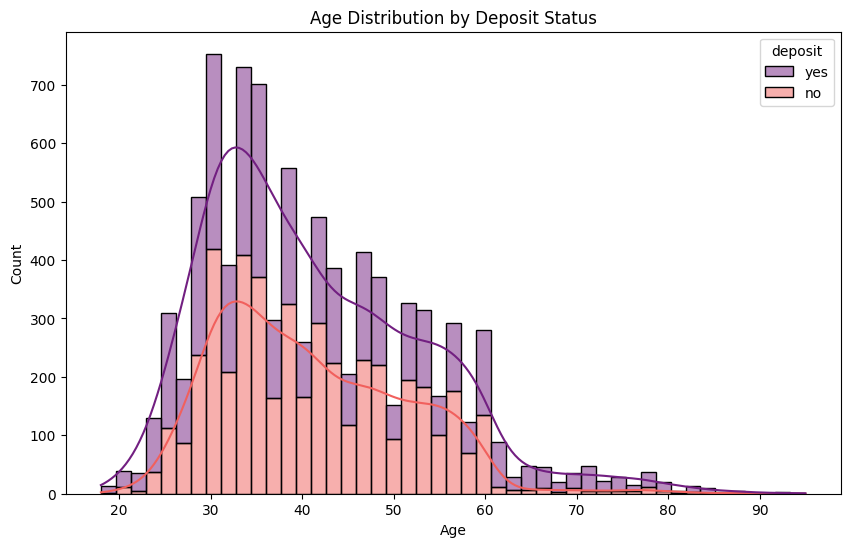

In [ ]:
# هل العمر بيفرق

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='deposit', kde=True, palette='magma', multiple="stack")
plt.title('Age Distribution by Deposit Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 30:40 ---> NO
# under 25, --> YES

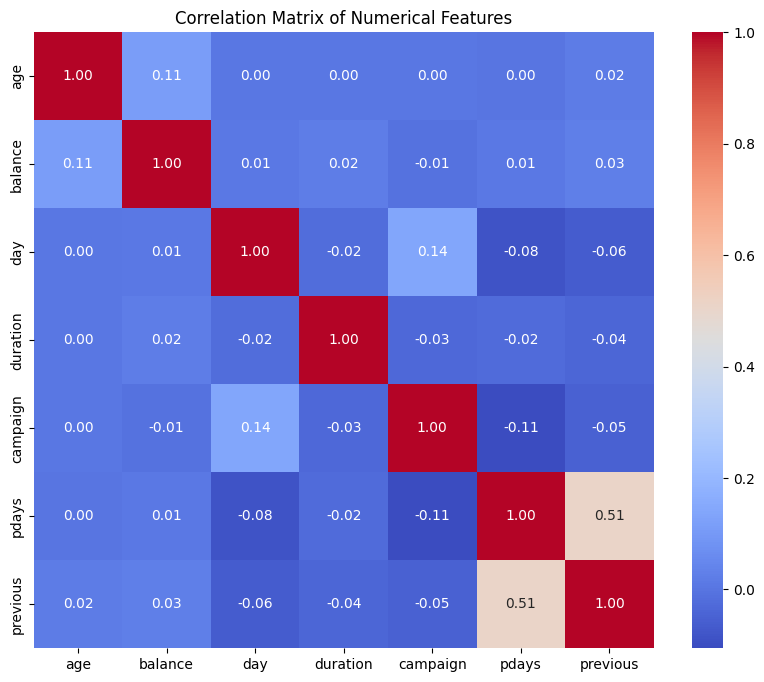

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# lb ---> target
# binary ---> housing', 'loan', 'default
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()

y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

In [ ]:
binary_cols = ['housing', 'loan', 'default']
for col in binary_cols:
    X_train[col] = X_train[col].map({'yes': 1, 'no': 0})
    X_test[col] = X_test[col].map({'yes': 1, 'no': 0})

In [ ]:
X_train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X_train.select_dtypes(include=['object']).columns

le = LabelEncoder()

for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7122 entries, 0 to 7121
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        7122 non-null   int64  
 1   job        7122 non-null   int64  
 2   marital    7122 non-null   int64  
 3   education  7122 non-null   int64  
 4   default    7122 non-null   int64  
 5   balance    7122 non-null   float64
 6   housing    7122 non-null   int64  
 7   loan       7122 non-null   int64  
 8   contact    7122 non-null   int64  
 9   day        7122 non-null   float64
 10  month      7122 non-null   int64  
 11  duration   7122 non-null   float64
 12  campaign   7122 non-null   float64
 13  pdays      7122 non-null   float64
 14  previous   7122 non-null   float64
 15  poutcome   7122 non-null   int64  
dtypes: float64(6), int64(10)
memory usage: 890.4 KB
None


In [ ]:
X_train.drop(columns=['job'])
X_test.drop(columns=['job'])

,age,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,29,1,2,0,318.0,1,0,0,18.0,8,1434.0,2.0,356.0,4.0,0
1,53,1,1,0,1776.0,0,0,0,18.0,6,443.0,7.0,-1.0,0.0,0
2,33,2,2,0,1107.0,1,0,0,18.0,7,201.0,1.0,-1.0,0.0,0
3,59,2,0,0,7724.0,0,0,0,21.0,9,373.0,3.0,-1.0,0.0,0
4,32,1,1,0,-242.0,1,0,0,20.0,0,1202.0,3.0,-1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,50,0,1,0,-194.0,1,0,0,13.0,0,238.0,2.0,-1.0,0.0,0
1777,27,2,1,0,535.0,0,0,0,16.0,9,183.0,1.0,94.0,1.0,2
1778,45,1,0,0,0.0,1,0,0,2.0,3,570.0,2.0,-1.0,0.0,0
1779,26,2,1,0,2509.0,0,0,0,19.0,3,654.0,3.0,-1.0,0.0,0


In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. حل مشكلة عدم تساوي عدد الصفوف (المزامنة)
y_train = y_train[X_train.index]

# 2. تحديد الأعمدة الرقمية
num_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

# 3. تطبيق الـ RobustScaler
scaler = RobustScaler()

# الـ Fit والـ Transform على الـ Train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# الـ Transform فقط على الـ Test
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Scaling completed using RobustScaler.")

Scaling completed using RobustScaler.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression(C=1.0, penalty='l2', solver='liblinear', max_iter=1000)

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Tuned Logistic Regression Accuracy: {accuracy_lr}")

Tuned Logistic Regression Accuracy: 0.7849522740033689


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn}")

KNN Accuracy: 0.7400336889387984


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


model_svm = SVC(kernel='rbf', C=1, gamma='scale')

model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)

print(f"SVM Tuned Accuracy: {accuracy_score(y_test, y_pred_svm)}")

SVM Tuned Accuracy: 0.7220662549129703


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb}")

Naive Bayes Accuracy: 0.7389107243121842
